In [7]:
import os

# uncomment to disable NVIDIA GPUs
#os.environ['CUDA_VISIBLE_DEVICES'] = ''
# or pick the device (cpu, gpu, and tpu)
#os.environ['JAX_PLATFORMS'] = 'cpu'

# change JAX GPU memory preallocation fraction
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '.95'

# you do not want this
#os.environ['XLA_FLAGS'] = '--xla_gpu_deterministic_ops=true'

import jax
#jax.print_environment_info()

!nvidia-smi --query-gpu=gpu_name --format=csv,noheader

NVIDIA GeForce GTX 1060 6GB


/home/pvinig/.pyenv/versions/anaconda3-2024.10-1/lib/python3.12/pty.py:95: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


In [8]:
import matplotlib.pyplot as plt
import matplotlib_inline


matplotlib_inline.backend_inline.set_matplotlib_formats('jpeg')

from pmwd import (
    Configuration,
    Cosmology, SimpleLCDM,
    boltzmann, linear_power, growth,
    white_noise, linear_modes,
    lpt,
    nbody,
    scatter,
)
from pmwd.pm_util import fftinv
from pmwd.spec_util import powspec
from pmwd.vis_util import simshow

In [9]:
if jax.default_backend() == 'gpu':
    ptcl_spacing = 1.  # Lagrangian space Cartesian particle grid spacing, in Mpc/h by default
    ptcl_grid_shape = (128,) * 3
else:
    ptcl_spacing = 4.
    ptcl_grid_shape = (64,) * 3

conf = Configuration(ptcl_spacing, ptcl_grid_shape, mesh_shape=2)  # 2x mesh shape

print(conf)  # with other default parameters
print(f'\n Simulating {conf.ptcl_num} particles with a {conf.mesh_shape} mesh for {conf.a_nbody_num} time steps.')

Configuration(ptcl_spacing=1.0,
              ptcl_grid_shape=(128, 128, 128),
              mesh_shape=(256, 256, 256),
              cosmo_dtype=dtype('float64'),
              pmid_dtype=dtype('int16'),
              float_dtype=dtype('float32'),
              k_pivot_Mpc=0.05,
              T_cmb=2.7255,
              M=1.98847e+40,
              L=3.0856775815e+22,
              T=3.0856775815e+17,
              transfer_fit=True,
              transfer_fit_nowiggle=False,
              transfer_lgk_min=-4,
              transfer_lgk_max=3,
              transfer_lgk_maxstep=0.0078125,
              growth_rtol=1.4901161193847656e-08,
              growth_atol=1.4901161193847656e-08,
              growth_inistep=(1, None),
              lpt_order=2,
              a_start=0.015625,
              a_stop=1,
              a_lpt_maxstep=0.0078125,
              a_nbody_maxstep=0.015625,
              symp_splits=((0, 0.5), (1, 0.5)),
              chunk_size=16777216)

 Simulating 2097

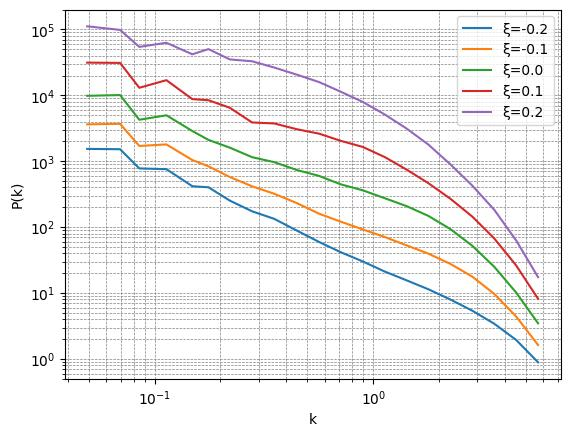

In [10]:
def nolin_ps(cosmo, modes):
    cosmo = jax.block_until_ready(boltzmann(cosmo, conf))
    modes = linear_modes(modes, cosmo, conf)
    ptcl, obsvbl = jax.block_until_ready(lpt(modes, cosmo, conf))
    ptcl, obsvbl = jax.block_until_ready(nbody(ptcl, obsvbl, cosmo, conf))
    dens = scatter(ptcl, conf)
    return powspec(dens, conf.cell_size)[:2]

cosmology = Cosmology(conf, A_s_1e9=2.0, n_s=0.96, Omega_m=0.3, Omega_b=0.05, h=0.7, xi_= 0.0, w_0_ =-1.0)
modes = white_noise(0, conf)

xis = [-0.2, -0.1, 0.0, +0.1, +0.2]
fig, ax = plt.subplots()
for xi in xis:
    cosmo = cosmology.replace(xi_=xi)
    k, P   = nolin_ps(cosmo, modes)
    ax.loglog(k, P, label=f'ξ={xi}')
ax.set(xlabel='k', ylabel='P(k)')
ax.legend()
plt.grid(True, which='both', ls='--', lw=0.5, color='gray')
plt.show()

In [11]:
rho_crit = conf.rho_crit
print(rho_crit)

27.752823482245116


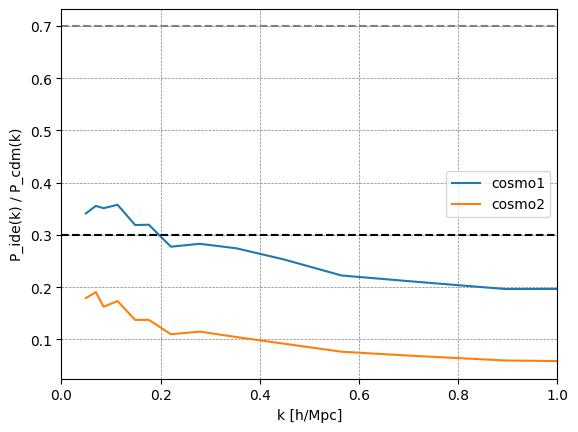

In [ ]:
seed      = 1
modes    = white_noise(seed, conf)


cosmo_cdm =    Cosmology(conf, A_s_1e9=2.1, n_s=0.96, Omega_m=0.31, Omega_b=0.05, h=0.67, xi_=0.0, w_0_=-1.0, w_a_= 0.0)
cosmo1 =       Cosmology(conf, A_s_1e9=2.1, n_s=0.96, Omega_m=0.29, Omega_b=0.05, h=0.68, xi_=-0.1, w_0_=-1.0, w_a_=0.0)
cosmo2 =       Cosmology(conf, A_s_1e9=2.1, n_s=0.96, Omega_m=0.22, Omega_b=0.05, h=0.71, xi_=-0.1, w_0_=-1.0, w_a_=0.0)

fig, ax = plt.subplots()


k_ref, P_ref = nolin_ps(cosmo_cdm, modes)
k1, p1 = nolin_ps(cosmo1, modes)
k2, p2 = nolin_ps(cosmo2, modes)



ax.plot(k1, p1/P_ref, label='cosmo1')
ax.plot(k2, p2/P_ref, label='cosmo2')

#ax.set_xscale('log')
ax.set_xlim(0 , 1)
ax.set_xlabel('k [h/Mpc]')
ax.set_ylabel('P_ide(k) / P_cdm(k)')
ax.axhline(0.7, color='gray', linestyle='--')
ax.axhline(0.3, color='black', linestyle='--')
ax.legend()
plt.grid(True, which='both', ls='--', lw=0.5, color='gray')
plt.show()